# QualityPhys - Camera Remote Vital Signs Estimator (CRVSE) Project

## NB_P3_15 - VitalVideos (WorldWide) raw dataset exploration (Phase 3)

Establishes the on-disk layout, ground-truth structure, and video/label
synchronization of the VitalVideos WorldWide subset before any preprocessing loader
is written. VitalVideos (Toye et al.; academic license, ~300 participants, delivered
over FTP) is the first dataset in this corpus to provide a research-grade 500 Hz
respiration waveform and 3-lead ECG recorded synchronously with the face video,
alongside a PPG waveform, per-participant Fitzpatrick skin tone, and before/after
cuff blood pressure. It is therefore the intended backbone for the respiration (RR)
head — which every existing training set leaves unlabelled — and a source of gold
beat timing for HRV.



## Imports & Setup

In [1]:
import json, cv2
from pathlib import Path
import numpy as np
import mediapipe as mp
import matplotlib.pyplot as plt
from scipy.signal import detrend, find_peaks, butter, filtfilt, resample_poly

from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision

ROOT = Path(r'E:\VitalsVideos')

samples = sorted(ROOT.rglob('*.json'))
print(f'found {len(samples)} sample JSON(s) under {ROOT}')
for js in samples:
    guid = js.stem
    mp4 = [m.name for m in js.parent.glob(f'{guid}*.mp4')]
    mov = [m.name for m in js.parent.glob('*.MOV')] + [m.name for m in js.parent.glob('*.mov')]
    print(f'{guid[:12]}… | json {js.name} | mp4 {mp4} | mov {mov}')

found 2 sample JSON(s) under E:\VitalsVideos
01d8e9a04532… | json 01d8e9a045324c078970b530c1e4e924.json | mp4 ['01d8e9a045324c078970b530c1e4e924_1.mp4'] | mov ['IMG_0507.MOV', 'IMG_0507.MOV']
0216c80cb7e8… | json 0216c80cb7e8496b8756e4159a79201a.json | mp4 ['0216c80cb7e8496b8756e4159a79201a_1.mp4'] | mov ['IMG_3846.MOV', 'IMG_3846.MOV']


## Map the JSON ground-truth structure

Loads each downloaded sample's JSON and prints its schema: participant demographics
(gender, age, Fitzpatrick skin tone) and free-text notes, location and environment,
and, per scenario, the recording block. For every scenario the CMS (consumer
pulse-oximeter) and BIO (research-grade, 500 Hz) streams are summarized by header,
row count, span and effective sampling rate, and the before/after cuff blood pressure
is echoed. The BIO block is parsed by header name so an absent MS_SINCE_START column
is handled, and the per-scenario cms_sampling_rate reported by the device is read
rather than assumed. A single reusable inspection function is applied across every
sample.

In [2]:
def inspect_sample(js_path):
    '''Prints the JSON schema and the CMS/BIO rates, spans, and channel ranges for one VitalVideos sample.'''
    with open(js_path) as f:
        d = json.load(f)
    print('=' * 72)
    print('GUID :', d.get('GUID'))
    print('top keys   :', list(d.keys()))
    print('participant:', d.get('participant'))
    print('location   :', d.get('location'))
    print('n scenarios:', len(d.get('scenarios', [])))
    for i, s in enumerate(d['scenarios']):
        rec = s['recordings']
        print(f'-- scenario {i}:', s.get('scenario_data'))
        print('   recordings keys:', list(rec.keys()))
        print('   BPbefore:', rec.get('BPbefore', {}).get('value'),
              '| BPafter:', rec.get('BPafter', {}).get('value'))
        cms = rec.get('CMS')
        if cms:
            hdr, arr = cms[0], np.array(cms[1:], dtype=float)
            t = arr[:, hdr.index('time')]; span = (t[-1] - t[0]) / 1000.0
            print(f'   CMS  {hdr} | rows {len(arr)} | span {span:.2f}s | eff.rate {(len(arr)-1)/span:.2f}Hz')
        bio = rec.get('BIO')
        if bio:
            hdr, arr = bio[0], np.array(bio[1:], dtype=float)
            seq = arr[:, hdr.index('SEQ')]; span = (seq[-1] - seq[0]) * 2 / 1000.0   # SEQ*2ms = timestamp
            print(f'   BIO  {hdr} | rows {len(arr)} | span {span:.2f}s (via SEQ*2ms) | rate {(len(arr)-1)/span:.1f}Hz')
            for col in ['PPG', 'ECG', 'RR']:
                if col in hdr:
                    v = arr[:, hdr.index(col)]
                    print(f'        {col:3s} min {v.min():.0f} max {v.max():.0f} mean {v.mean():.0f} span {v.max()-v.min():.0f}')

for js in samples:
    inspect_sample(js)

GUID : 01d8e9a045324c078970b530c1e4e924
top keys   : ['GUID', 'consent', 'time', 'participant', 'location', 'scenarios']
participant: {'gender': 'F', 'age': '48', 'fitzpatrick': '6', 'forearm_length': '', 'p_notes': '145/92; bad breathing signal'}
location   : {'location': 'CH', 'environment': 'outdoor'}
n scenarios: 1
-- scenario 0: {'scenario': 'faceonly', 's_notes': '', 'ext_vid_name': 'IMG_0507', 'cms_sampling_rate': 59.55}
   recordings keys: ['CMS', 'BIO', 'RGB', 'BPbefore', 'BPafter']
   BPbefore: 145/92 | BPafter: 139/92
   CMS  ['time', 'ppg', 'hr', 'spo2'] | rows 3573 | span 60.02s | eff.rate 59.51Hz
   BIO  ['SEQ', 'PPG', 'ECG', 'RR'] | rows 30015 | span 60.03s (via SEQ*2ms) | rate 500.0Hz
        PPG min 14634 max 57744 mean 32780 span 43110
        ECG min 21528 max 65032 mean 32732 span 43504
        RR  min 22346 max 24300 mean 23209 span 1954
GUID : 0216c80cb7e8496b8756e4159a79201a
top keys   : ['GUID', 'consent', 'time', 'participant', 'location', 'scenarios']
particip

## Video geometry

Reads the container properties of both videos accompanying each sample - the fixed
node-camera MP4 and the iPhone MOV named in ext_vid_name - to establish frame rate,
frame count, resolution and duration, and to confirm the codec actually decodes. This
determines which stream the preprocessing loader will consume and whether the face
resolution supports the 72x72 crop. No frame is displayed; a single frame is decoded
only to verify the codec, then discarded.

In [3]:
def video_geometry(path):
    '''Reads container properties (fps, frame count, resolution, duration) and confirms the codec decodes one frame, without rendering it.'''
    cap = cv2.VideoCapture(str(path))
    opened = cap.isOpened()
    fps = cap.get(cv2.CAP_PROP_FPS)
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    grabbed, _ = cap.read() # decode-check only; frame discarded, never shown
    cap.release()
    dur = n / fps if fps else float('nan')
    return dict(opened=opened, decodes=bool(grabbed), fps=round(fps, 3),
                frames=n, res=f'{w}x{h}', duration_s=round(dur, 2))

for js in samples:
    guid = js.stem
    mp4 = next(js.parent.glob(f'{guid}*.mp4'), None)
    mov = next(js.parent.glob('*.MOV'), None)
    print('=' * 72)
    print('GUID:', guid[:12], '…')
    for tag, p in [('mp4', mp4), ('mov', mov)]:
        print(f'{tag}: {p.name if p else "(missing)"} ->', video_geometry(p) if p else None)

GUID: 01d8e9a04532 …
mp4: 01d8e9a045324c078970b530c1e4e924_1.mp4 -> {'opened': True, 'decodes': True, 'fps': 60.0, 'frames': 3600, 'res': '960x1056', 'duration_s': 60.0}
mov: IMG_0507.MOV -> {'opened': True, 'decodes': True, 'fps': 59.96, 'frames': 3599, 'res': '1080x1920', 'duration_s': 60.02}
GUID: 0216c80cb7e8 …
mp4: 0216c80cb7e8496b8756e4159a79201a_1.mp4 -> {'opened': True, 'decodes': True, 'fps': 60.0, 'frames': 3600, 'res': '960x1056', 'duration_s': 60.0}
mov: IMG_3846.MOV -> {'opened': True, 'decodes': True, 'fps': 59.958, 'frames': 3599, 'res': '1080x1920', 'duration_s': 60.02}


## Validate the BIO ground truth and the 60-second sync

Cross-checks the three independent physiological references against one another to
confirm both the channel identities and the release's "all streams span 60 s" sync
convention. Heart rate is estimated three ways - the spectral peak of the BIO PPG in
the cardiac band (0.7–3.3 Hz), R-peak detection on the BIO ECG, and the
device-reported CMS heart rate - and agreement across the three establishes that the
waveforms are what the documentation states and that no timing drift has been
introduced. The BIO respiration channel is then characterized on its own: its
spectral peak yields a breathing rate and a peak-power-fraction quality score in the
0.1–0.5 Hz band, as a first attempt at the respiration usability gate that the
preprocessing loader will require. Only the physiological waveforms are plotted.

01d8e9a04532… | F/48/fitz6 | p_notes '145/92; bad breathing signal'
  HR  bio-PPG  90.0 (sqi 0.60) | bio-ECG  91.2 | CMS  91.0 bpm
  RR  bio 26.0 br/min (sqi 0.58)
0216c80cb7e8… | M/43/fitz5 | p_notes ''
  HR  bio-PPG  73.0 (sqi 0.68) | bio-ECG 138.9 | CMS  72.0 bpm
  RR  bio 11.0 br/min (sqi 0.40)


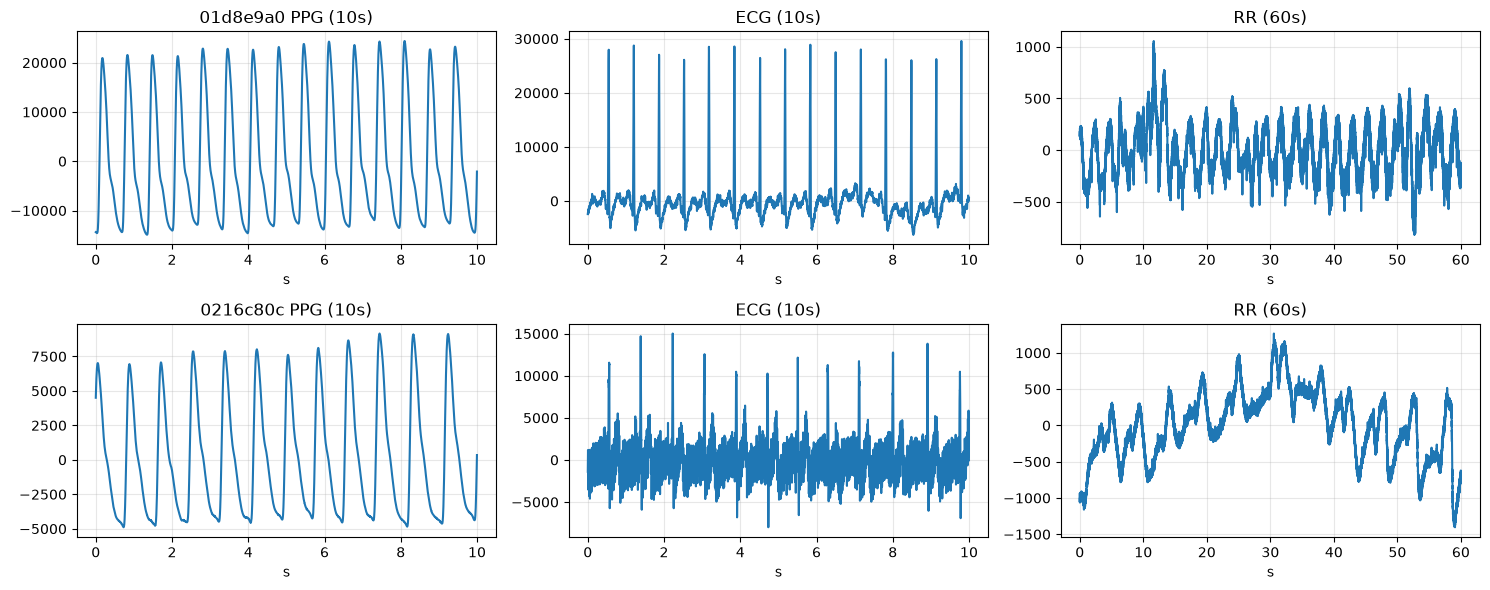

In [4]:
FS = 500.0

def load_bio(js_path):
    '''Returns the parsed JSON, the BIO channels by name, and the CMS device HR (median of valid samples).'''
    with open(js_path) as f:
        d = json.load(f)
    rec = d['scenarios'][0]['recordings']
    hdr = rec['BIO'][0]; arr = np.array(rec['BIO'][1:], dtype=float)
    cols = {c: arr[:, hdr.index(c)] for c in hdr}
    cms_hr = np.nan
    if rec.get('CMS'):
        chdr = rec['CMS'][0]; carr = np.array(rec['CMS'][1:], dtype=float)
        h = carr[:, chdr.index('hr')]; h = h[(h > 30) & (h < 220)]
        cms_hr = np.median(h) if len(h) else np.nan
    return d, cols, cms_hr

def band_peak(x, fs, lo, hi):
    '''Spectral peak rate (per minute) and 3-bin peak-power fraction (SQI) of x within [lo,hi] Hz.'''
    x = detrend(np.asarray(x, float))
    P = np.abs(np.fft.rfft(x * np.hanning(len(x)))) ** 2
    f = np.fft.rfftfreq(len(x), 1 / fs)
    b = (f >= lo) & (f <= hi)
    if not b.any() or P[b].sum() <= 0:
        return np.nan, 0.0
    pk = int(np.argmax(P[b]))
    return f[b][pk] * 60, float(P[b][max(0, pk - 1):pk + 2].sum() / P[b].sum())

def ecg_hr(ecg, fs):
    '''R-peak HR from the ECG channel, trying both polarities.'''
    x = detrend(np.asarray(ecg, float)); x = x / (x.std() + 1e-9)
    for sig in (x, -x):
        pks, _ = find_peaks(sig, distance=int(0.33 * fs), prominence=2.0)
        if len(pks) >= 3:
            hr = 60.0 / np.median(np.diff(pks) / fs)
            if 30 < hr < 220:
                return hr
    return np.nan

for js in samples:
    d, c, cms_hr = load_bio(js)
    p = d['participant']
    hr_ppg, sqi_ppg = band_peak(c['PPG'], FS, 0.7, 3.3)
    rr_rate, sqi_rr = band_peak(c['RR'], FS, 0.1, 0.5)
    print('=' * 72)
    print(f"{d['GUID'][:12]}… | {p['gender']}/{p['age']}/fitz{p['fitzpatrick']} | p_notes {p.get('p_notes','')!r}")
    print(f"  HR  bio-PPG {hr_ppg:5.1f} (sqi {sqi_ppg:.2f}) | bio-ECG {ecg_hr(c['ECG'], FS):5.1f} | CMS {cms_hr:5.1f} bpm")
    print(f"  RR  bio {rr_rate:4.1f} br/min (sqi {sqi_rr:.2f})")

fig, ax = plt.subplots(len(samples), 3, figsize=(15, 3 * len(samples))); ax = np.atleast_2d(ax)
for k, js in enumerate(samples):
    d, c, _ = load_bio(js); t = np.arange(len(c['PPG'])) / FS; w = t < 10
    ax[k, 0].plot(t[w], detrend(c['PPG'][w])); ax[k, 0].set(title=f"{d['GUID'][:8]} PPG (10s)", xlabel='s')
    ax[k, 1].plot(t[w], detrend(c['ECG'][w])); ax[k, 1].set(title='ECG (10s)', xlabel='s')
    ax[k, 2].plot(t, detrend(c['RR']));        ax[k, 2].set(title='RR (60s)', xlabel='s')
    for a in ax[k]: a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Harden the ECG R-peak detection and the respiration usability gate

Addresses the two weaknesses the previous step exposed on real signals: a naive
amplitude peak-finder double-counts heart rate on noisier ECG traces, and a plain
band peak-power score mis-ranks respiration quality because slow baseline drift and
broadband noise both inflate it. The ECG is band-pass filtered to the QRS band
(5-15 Hz), squared and integrated before refractory-spaced peak detection, and the
resulting heart rate is cross-checked against the PPG-spectral and CMS references. The
respiration channel is first de-drifted with a low-cut high-pass, after which its
breathing rate and a spectral-concentration quality score are computed in a
physiological band; the score is required to rank the note-flagged subject below the
clean one before it is trusted as the RR usability gate.

01d8e9a04532… | F/48/fitz6 | p_notes '145/92; bad breathing signal'
  HR  PPG  90.0 | ECG  90.9 (90 R-peaks) | CMS  91.0 bpm
  RR  26.0 br/min | concentration-SQI 0.53 | notes-flagged-bad True
0216c80cb7e8… | M/43/fitz5 | p_notes ''
  HR  PPG  73.0 | ECG  72.6 (72 R-peaks) | CMS  72.0 bpm
  RR  11.0 br/min | concentration-SQI 0.49 | notes-flagged-bad False


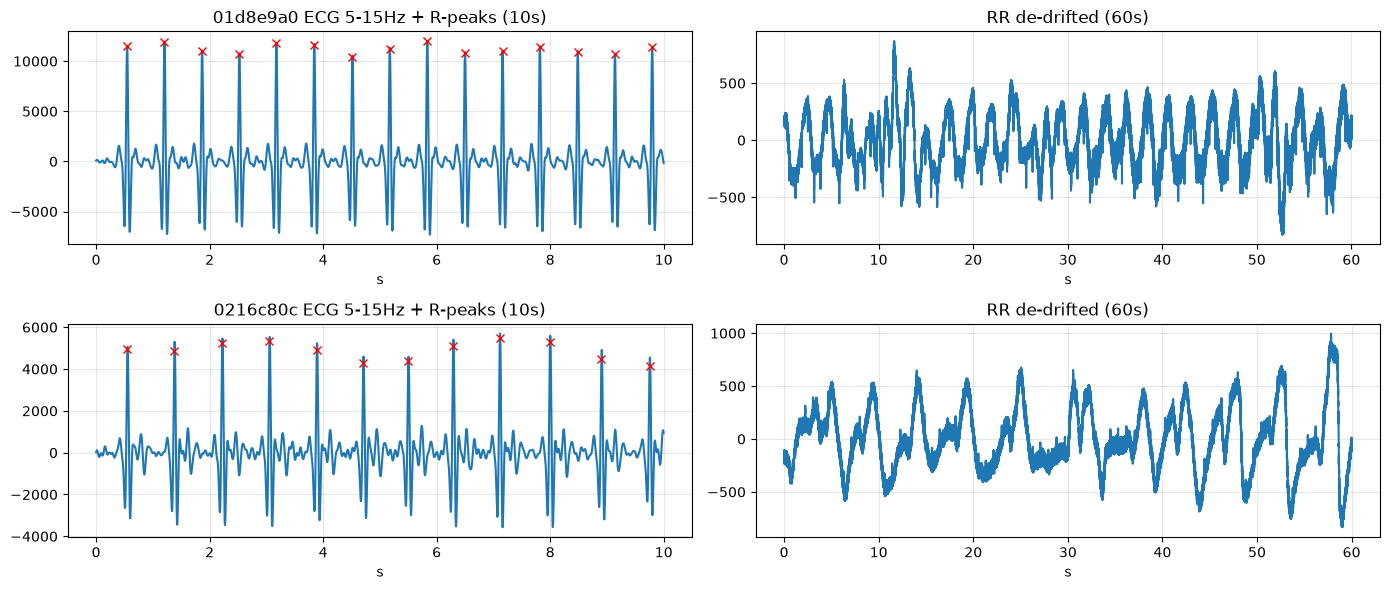

In [5]:
def _flt(x, lo, hi, fs, btype, order=3):
    ny = fs / 2.0
    if btype == 'band':
        b, a = butter(order, [lo / ny, hi / ny], btype='band')
    else:  # high-pass
        b, a = butter(order, lo / ny, btype='high')
    return filtfilt(b, a, np.asarray(x, float))

def ecg_rpeaks_hr(ecg, fs):
    '''Pan-Tompkins-lite HR: QRS band-pass (5-15 Hz) -> square -> 150 ms integrate -> refractory peak pick.'''
    x = _flt(detrend(np.asarray(ecg, float)), 5, 15, fs, 'band')
    integ = np.convolve(x ** 2, np.ones(max(1, int(0.15 * fs))) / max(1, int(0.15 * fs)), mode='same')
    thr = integ.mean() + 0.5 * integ.std()
    pks, _ = find_peaks(integ, distance=int(0.30 * fs), height=thr)
    hr = 60.0 / np.median(np.diff(pks) / fs) if len(pks) >= 3 else np.nan
    return hr, pks

def resp_rate_sqi(rr, fs, lo=0.1, hi=0.5):
    '''De-drifts respiration (high-pass 0.08 Hz), returns breathing rate and the fraction of spectral energy concentrated at the breathing peak.'''
    x = _flt(detrend(np.asarray(rr, float)), 0.08, None, fs, 'high')
    P = np.abs(np.fft.rfft(x * np.hanning(len(x)))) ** 2
    f = np.fft.rfftfreq(len(x), 1 / fs)
    total = P[(f > 0.05) & (f < 2.0)].sum()
    b = (f >= lo) & (f <= hi)
    if not b.any() or total <= 0:
        return np.nan, 0.0
    pk = int(np.argmax(P[b]))
    return f[b][pk] * 60, float(P[b][max(0, pk - 2):pk + 3].sum() / total)

for js in samples:
    d, c, cms_hr = load_bio(js)
    p = d['participant']
    hr_ppg, _ = band_peak(c['PPG'], FS, 0.7, 3.3)
    hr_ecg, rpks = ecg_rpeaks_hr(c['ECG'], FS)
    rr_rate, rr_sqi = resp_rate_sqi(c['RR'], FS)
    flagged = 'breath' in p.get('p_notes', '').lower()
    print('=' * 72)
    print(f"{d['GUID'][:12]}… | {p['gender']}/{p['age']}/fitz{p['fitzpatrick']} | p_notes {p.get('p_notes','')!r}")
    print(f"  HR  PPG {hr_ppg:5.1f} | ECG {hr_ecg:5.1f} ({len(rpks)} R-peaks) | CMS {cms_hr:5.1f} bpm")
    print(f"  RR  {rr_rate:4.1f} br/min | concentration-SQI {rr_sqi:.2f} | notes-flagged-bad {flagged}")

# eyeball the fixes (physiological signals only - no frames)
fig, ax = plt.subplots(len(samples), 2, figsize=(14, 3 * len(samples))); ax = np.atleast_2d(ax)
for k, js in enumerate(samples):
    d, c, _ = load_bio(js)
    xe = _flt(detrend(c['ECG'].astype(float)), 5, 15, FS, 'band'); t = np.arange(len(xe)) / FS; w = t < 10
    _, rp = ecg_rpeaks_hr(c['ECG'], FS); rp = rp[rp < 10 * FS]
    ax[k, 0].plot(t[w], xe[w]); ax[k, 0].plot(rp / FS, xe[rp], 'rx')
    ax[k, 0].set(title=f"{d['GUID'][:8]} ECG 5-15Hz + R-peaks (10s)", xlabel='s')
    xr = _flt(detrend(c['RR'].astype(float)), 0.08, None, FS, 'high')
    ax[k, 1].plot(np.arange(len(xr)) / FS, xr); ax[k, 1].set(title='RR de-drifted (60s)', xlabel='s')
    for a in ax[k]: a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## A periodicity-based respiration usability gate

The spectral concentration score still ranks the note-flagged subject above the clean
one, because the wide breathing band admits a fast, non-periodic noise peak. This step
replaces it with a periodicity measure: the respiration channel is de-drifted and
band-limited to the physiological resting range (0.1-0.4 Hz, 6-24 br/min), and the
height of the dominant peak of its normalized autocorrelation within that range is
taken as the quality score — high for a sustained breathing rhythm, low for noise. The
score is validated against the requirement that it rank the "bad breathing" subject
below the clean one, and cross-checked against the free-text p_notes flag.

In [6]:
def resp_quality(rr, fs, fs2=10.0, lo=0.1, hi=0.4):
    '''Downsamples respiration to fs2 Hz (for numerical stability), de-drifts, band-limits to the
    resting range, and scores periodicity by the dominant autocorrelation peak in the 6-24 br/min lags.'''
    x = resample_poly(np.asarray(rr, float), int(fs2), int(fs))    # 500 -> 10 Hz, anti-aliased
    x = _flt(detrend(x), 0.08, None, fs2, 'high')                  # de-drift
    x = _flt(x, lo, hi, fs2, 'band')                               # resting breathing band
    x = (x - x.mean()) / (x.std() + 1e-9)
    ac = np.correlate(x, x, mode='full')[len(x) - 1:]; ac = ac / ac[0]
    lo_lag, hi_lag = int(fs2 / hi), int(fs2 / lo)                  # 2.5 s .. 10 s
    seg = ac[lo_lag:hi_lag]
    if len(seg) < 2:
        return np.nan, 0.0
    pk = int(np.argmax(seg))
    rate = 60.0 / ((lo_lag + pk) / fs2)
    return rate, float(seg[pk])

for js in samples:
    d, c, _ = load_bio(js); p = d['participant']
    rate, q = resp_quality(c['RR'], FS)
    flagged = 'breath' in p.get('p_notes', '').lower()
    print(f"{d['GUID'][:12]}… | RR {rate:4.1f} br/min | periodicity-quality {q:.2f} | notes-flagged-bad {flagged}")

01d8e9a04532… | RR  6.8 br/min | periodicity-quality 0.11 | notes-flagged-bad True
0216c80cb7e8… | RR  7.5 br/min | periodicity-quality 0.13 | notes-flagged-bad False


In [7]:
def resp_summary(rr, fs, fs2=10.0, lo=0.1, hi=0.4):
    '''Rate from the spectral peak, quality from the autocorrelation peak height, on the downsampled de-drifted RR.'''
    x = resample_poly(np.asarray(rr, float), int(fs2), int(fs))
    x = _flt(detrend(x), 0.08, None, fs2, 'high')
    xb = _flt(x, lo, hi, fs2, 'band'); xb = (xb - xb.mean()) / (xb.std() + 1e-9)
    P = np.abs(np.fft.rfft(xb * np.hanning(len(xb)))) ** 2; f = np.fft.rfftfreq(len(xb), 1 / fs2)
    band = (f >= lo) & (f <= hi)
    rate = f[band][np.argmax(P[band])] * 60 if band.any() and P[band].sum() > 0 else np.nan
    ac = np.correlate(xb, xb, mode='full')[len(xb) - 1:]; ac = ac / ac[0]
    seg = ac[int(fs2 / hi):int(fs2 / lo)]
    return rate, (float(seg.max()) if len(seg) else 0.0)

for js in samples:
    d, c, _ = load_bio(js); p = d['participant']
    rate, q = resp_summary(c['RR'], FS)
    print(f"{d['GUID'][:12]}… | RR {rate:4.1f} br/min | quality {q:.2f} | flagged {'breath' in p.get('p_notes','').lower()}")

01d8e9a04532… | RR  7.0 br/min | quality 0.11 | flagged True
0216c80cb7e8… | RR 11.0 br/min | quality 0.13 | flagged False


## Face-crop feasibility and frame-to-signal alignment

Confirms that the node-camera MP4 supports the model input pipeline and that the
ground-truth waveforms align to its frames. Frames sampled evenly across the recording
are passed to the MediaPipe face landmarker numerically - no frame is displayed — to
measure the face-detection rate, the median face bounding-box size relative to the
72x72 crop target, and the stability of the face centre across the minute. The
alignment step then resamples the 500 Hz BIO PPG onto the video frame grid, treating
both as spanning a fixed 60 s and taking BIO timestamps from SEQ, and verifies that
the spectral heart rate of the frame-synced waveform matches the native reference —
establishing the label construction the preprocessing loader will use.

In [8]:
MODEL = Path(r'D:\code\QualityPhys - CRVSE Project\app\live_hr_demo\models\mediapipe\face_landmarker.task')
print('landmarker model present:', MODEL.exists())

def make_landmarker():
    opts = vision.FaceLandmarkerOptions(
        base_options=mp_python.BaseOptions(model_asset_path=str(MODEL)),
        running_mode=vision.RunningMode.IMAGE, num_faces=1,
        min_face_detection_confidence=0.3, min_face_presence_confidence=0.3)
    return vision.FaceLandmarker.create_from_options(opts)

def face_survey(mp4_path, lm, k=20):
    '''Samples k frames and detects the face numerically, returning detection rate, face size, and centre stability (no frame shown).'''
    cap = cv2.VideoCapture(str(mp4_path))
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)); W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)); H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    sizes, cx, cy, hits = [], [], [], 0
    idx = np.linspace(0, n - 1, k).astype(int)
    for i in idx:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(i)); ok, fr = cap.read()
        if not ok:
            continue
        img = mp.Image(image_format=mp.ImageFormat.SRGB, data=cv2.cvtColor(fr, cv2.COLOR_BGR2RGB))
        res = lm.detect(img)
        if not res.face_landmarks:
            continue
        p = np.array([[l.x * W, l.y * H] for l in res.face_landmarks[0]])
        sizes.append(max(np.ptp(p[:, 0]), np.ptp(p[:, 1]))); cx.append(p[:, 0].mean()); cy.append(p[:, 1].mean()); hits += 1
    cap.release()
    return dict(frame=f'{W}x{H}', sampled=len(idx), detect_rate=round(hits / len(idx), 2),
                face_px_median=round(float(np.median(sizes)), 1) if sizes else None,
                face_px_min=round(float(np.min(sizes)), 1) if sizes else None,
                centre_std_px=(round(float(np.std(cx)), 1), round(float(np.std(cy)), 1)) if cx else None)

lm = make_landmarker()
for js in samples:
    mp4 = next(js.parent.glob(f'{js.stem}*.mp4'), None)
    print('=' * 72); print(js.stem[:12], '…', face_survey(mp4, lm) if mp4 else '(no mp4)')

# frame-to-signal alignment: resample 500 Hz BIO PPG onto the 60 fps frame grid (both span 60 s, SEQ timestamps)
print('-' * 72)
for js in samples:
    d, c, _ = load_bio(js)
    t_sig = c['SEQ'] * 2.0 / 1000.0 # BIO timestamps in seconds (SEQ*2ms)
    t_frm = np.arange(3600) / 60.0 # 60 fps frame grid, 60 s
    ppg_frames = np.interp(t_frm, t_sig, c['PPG'])
    hr_frame, _ = band_peak(ppg_frames, 60.0, 0.7, 3.3)
    hr_native, _ = band_peak(c['PPG'], FS, 0.7, 3.3)
    print(f"{js.stem[:12]}… | HR native {hr_native:.1f} | on 60 fps frame grid {hr_frame:.1f} bpm")

landmarker model present: True
01d8e9a04532 … {'frame': '960x1056', 'sampled': 20, 'detect_rate': 1.0, 'face_px_median': 341.5, 'face_px_min': 329.3, 'centre_std_px': (29.5, 7.6)}
0216c80cb7e8 … {'frame': '960x1056', 'sampled': 20, 'detect_rate': 1.0, 'face_px_median': 447.7, 'face_px_min': 445.8, 'centre_std_px': (2.5, 1.3)}
------------------------------------------------------------------------
01d8e9a04532… | HR native 90.0 | on 60 fps frame grid 90.0 bpm
0216c80cb7e8… | HR native 73.0 | on 60 fps frame grid 73.0 bpm


## Conclusions and preprocessing specification

The VitalVideos WorldWide sample is characterized end to end. Each recording pairs a
60-second node-camera MP4 (60 fps, 960x1056) and an iPhone MOV with a JSON carrying
participant demographics including Fitzpatrick skin tone, before/after cuff blood
pressure, a consumer CMS pulse-oximeter stream, and a research-grade BIO stream
(500 Hz PPG, ECG, and respiration). The MP4 is selected as the model input: a face is
detected on every sampled frame at roughly 330-450 px, comfortably downscaled to the
72x72 crop, with limited head motion.

Ground-truth quality is established per channel. Heart rate agrees across the BIO PPG
spectrum, the ECG R-peaks (via a QRS-band, integrated, refractory detector), and the
CMS device value, and serves as the product-grade label; the ECG additionally provides
beat-to-beat timing for HRV. The respiration channel is usable but not guaranteed —
it requires downsampling to about 10 Hz, baseline-drift removal, and a periodicity
quality score (autocorrelation peak height in the resting band) combined with the
free-text notes flag, so that poor breathing traces are down-weighted rather than
trusted.
